# BCO7006 — Session 12 · INSTRUCTOR
# APIs and HTTP Requests

Instructor copy: exercises solved, common-wrong-answer notes, L5 rubric, AI-disclosure guidance. **Do not distribute.**

> 🧑‍🏫 **Instructor note** — **Before class:** open `https://fakestoreapi.com/products` in a browser to confirm it's up. If it's down, the notebook still runs — it falls back to `fakestore_products.json` — but you'll want to show students a real `200`. Keep the JSON file in the same folder as the notebook in VUC/Colab.

## 2 · First request

In [1]:
import requests
API_URL = "https://fakestoreapi.com/products"
try:
    response = requests.get(API_URL, timeout=5)
    print("Status code:", response.status_code)
    print("Type:", type(response))
except Exception as e:
    print("No live connection — cached data will be used below. (", type(e).__name__, ")")

Status code: 403
Type: <class 'requests.models.Response'>


> 🧑‍🏫 **Instructor note** — Trace answer: `GET /products/9999` returns **404** (not found). A frequent wrong answer is **400** — clarify that the request itself is well-formed; the *resource* just doesn't exist, which is 404.

## 3 · Helper

In [2]:
import json
def fetch_products():
    try:
        resp = requests.get(API_URL, timeout=5)
        resp.raise_for_status()
        return resp.json(), "live API"
    except Exception:
        with open("fakestore_products.json") as f:
            return json.load(f), "cached file"
products, source = fetch_products()
print(f"Loaded {len(products)} products from the {source}.")

Loaded 12 products from the cached file.


> 🧑‍🏫 **Instructor note** — `raise_for_status()` is the teaching point: it converts a 4xx/5xx into a Python exception so the `except` can catch it. Without it, a 404 response is still a 'successful' call as far as `requests` is concerned and the fallback wouldn't fire.

## 4 · JSON navigation

In [3]:
first = products[0]
print(type(first)); first

<class 'dict'>


{'id': 1,
 'title': 'Classic Cotton T-Shirt',
 'price': 22.3,
 'category': "men's clothing",
 'description': 'Soft everyday cotton tee.',
 'rating': {'rate': 3.9, 'count': 120}}

In [4]:
print(first['title'], first['price'], first['category'], first['rating']['rate'])

Classic Cotton T-Shirt 22.3 men's clothing 3.9


**Pause-and-try solution — third product's title and price:**

In [5]:
third = products[2]
print(third['title'], "-", third['price'])

Insulated Winter Jacket - 109.95


> 🧑‍🏫 **Instructor note** — Two classic errors: indexing the list with `products['title']` (treating the list like a dict) → TypeError; and forgetting the nested step `['rating']['rate']`, trying `first['rate']` → KeyError.

## 5 · Params

In [6]:
try:
    resp = requests.get(API_URL, params={"limit": 3}, timeout=5)
    print(resp.url); print(len(resp.json()), "products")
except Exception:
    print("Offline — params={'limit': 3} -> '?limit=3' -> server returns 3.")

https://fakestoreapi.com/products?limit=3
Offline — params={'limit': 3} -> '?limit=3' -> server returns 3.


## 6 · DataFrame

In [7]:
import pandas as pd
products_df = pd.DataFrame(products)
products_df['rating_value'] = products_df['rating'].apply(lambda r: r['rate'])
products_df[['id','title','price','category','rating_value']].head()

,id,title,price,category,rating_value
0,1,Classic Cotton T-Shirt,22.30,men's clothing,3.9
1,2,Slim Fit Jeans,55.99,men's clothing,4.1
2,3,Insulated Winter Jacket,109.95,men's clothing,4.7
3,4,Women's Knit Sweater,39.99,women's clothing,3.5
4,5,Summer Floral Dress,49.00,women's clothing,4.2


## 7 · Mini-project — reference answers

category
jewelery            352.995000
electronics         181.995000
men's clothing       62.746667
women's clothing     51.163333
Name: price, dtype: float64


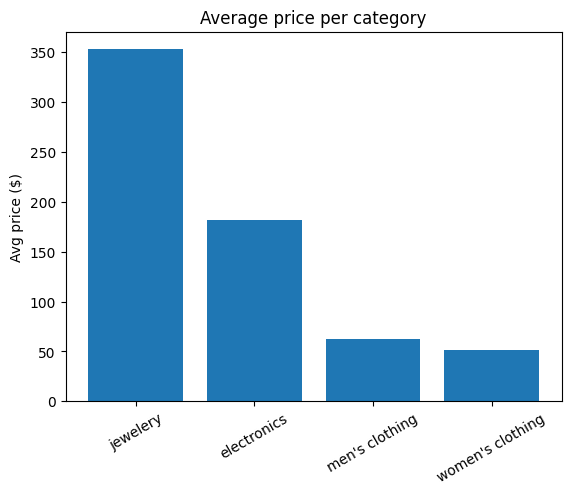

In [8]:
# Q1 — average price per category
import matplotlib.pyplot as plt
avg = products_df.groupby('category')['price'].mean().sort_values(ascending=False)
print(avg)
plt.bar(avg.index, avg.values); plt.xticks(rotation=30)
plt.title('Average price per category'); plt.ylabel('Avg price ($)'); plt.show()

In [9]:
# Q2 — highest-rated product
top = products_df.loc[products_df['rating_value'].idxmax()]
print(top['title'], "-", top['rating_value'])

Portable SSD 1TB - 4.8


In [10]:
# Q3 — count over $100
print((products_df['price'] > 100).sum(), "products cost more than $100")

5 products cost more than $100


> 🧑‍🏫 **Instructor note** — **L5 (open question) rubric — engagement-based.** Pass = a *different* no-auth API actually fetched, converted to a DataFrame, one fact stated. Distinction = handles the response defensively (checks status or wraps in try/except) and the 'fact' reflects a real read of the data. Don't penalise choice of API; reward that they made a live call work and reasoned about the shape of what came back.

## 8 · AI critique — reference

> 🧑‍🏫 **Instructor note** — Three faults to elicit: (1) `requests.get(...)` returns a **response object**, not the data — you must call `.json()`; (2) so `data[0]` indexes the response object → TypeError; (3) no status check / error handling, so a network hiccup crashes the script. The fix adds `.json()` and a guard.

In [11]:
import requests
try:
    resp = requests.get("https://fakestoreapi.com/products", timeout=5)
    resp.raise_for_status()
    data = resp.json()                 # <-- the missing step
    print(data[0]["title"])
except Exception as e:
    print("Request failed:", type(e).__name__)

Request failed: HTTPError


> 🧑‍🏫 **Instructor note** — **AI-disclosure guidance.** The give-away of unedited AI code here is the *absence* of `.json()` or error handling combined with a confident reflection — or, conversely, code that uses an auth header for an API that needs none. Calibrated response: ask the student to run their cell live and explain what `requests.get` returns. Keep it a conversation, not a referral.